# CEF deep-dive: Oxford Lane at the center

Thin driver notebook: all logic lives in `src/cef/`. Framing: listed CLO closed-end funds (Oxford Lane Capital Corp., OXLC, at the center; Eagle Point Credit, ECC, alongside) are **permanent capital that converts retail demand into primary CLO equity orders** — their capital formation is upstream of CLO formation.

**The centerpiece — the premium-funded ATM flywheel** (`analysis_capital_machine.py`, `viz_flywheel.py`): OXLC's own EDGAR 424B3/497 prospectus supplements disclose, in plain sentences, exactly how many ATM shares were sold and at what proceeds since the last supplement, *and* a preliminary NAV-per-share estimate at scattered month-ends. Joining those against OXLC's market price gives a **real historical premium/discount series** — richer than Section 2's own premium/discount table, which is limited to a single current-day book-value snapshot (yfinance has no historical NAV for these tickers).

**A real bug, caught and fixed along the way**: OXLC underwent a 1-for-5 reverse split on 2025-09-08. Yahoo Finance's historical "Close" price turned out to be retroactively split-adjusted (not just dividend-adjusted, despite the naming), while the scraped NAV disclosures were not — the first pass through this pipeline produced a nonsense 813% "premium" for April 2020 before the mismatch was traced and fixed (`scrape_preferreds.scrape_stock_splits`, `analysis_capital_machine._cumulative_split_factor`; regression test in `tests/test_analysis_capital_machine.py`).

**Extends into**: cost of capital (preferred/baby-bond yields vs. portfolio effective yield), distribution-cut resilience (does the premium survive a cut?), portfolio shelf/vintage concentration (NPORT-P), the NAV-translation leverage gradient (JAAA -> BKLN -> OXLC/ECC, teaching the whole capital structure through instruments a desk can quote), and a 13G-based institutional-ownership floor.

**Documented gap**: the demand-transmission chain's final link (issuance -> market-wide CLO new-issue equity conditions) needs Section 4's CLO issuance-cycle data, which is empty (SIFMA gated) — reported as a gap in `analysis_demand_transmission.py`, not silently dropped.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

from IPython.display import Image, display

from src.cef import (
    scrape_capital_actions, scrape_preferreds, scrape_13f_ownership,
    analysis_capital_machine, analysis_cost_of_capital, analysis_distribution_quality,
    analysis_portfolio_style, analysis_nav_translation, analysis_ownership, analysis_demand_transmission,
    viz_flywheel, viz_cost_of_capital, viz_distribution, viz_style, viz_wrapper,
    ledger,
)


/Users/zinuoshi/clo-atlas/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Scrape (raw -> interim)

In [2]:
RUN_SCRAPE = False
if RUN_SCRAPE:
    scrape_capital_actions.run()   # ATM tape, preferred series, NAV disclosures — from EDGAR 424B3/497
    scrape_preferreds.run()        # preferred/baby-bond prices + stock-split history
    scrape_13f_ownership.run()     # Schedule 13G/13G-A


## Analysis (interim -> final)

In [3]:
capital_machine = analysis_capital_machine.run()
cost_of_capital = analysis_cost_of_capital.run()
distribution_quality = analysis_distribution_quality.run()
portfolio_style = analysis_portfolio_style.run()
nav_translation = analysis_nav_translation.run()
ownership = analysis_ownership.run()
demand_transmission = analysis_demand_transmission.run()


## Viz (final -> figures/)

/Users/zinuoshi/clo-atlas/src/cef/viz_wrapper.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels([LABELS[t] for t in merged["ticker"]], fontsize=8.5)
/Users/zinuoshi/clo-atlas/src/cef/viz_wrapper.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels([LABELS[t] for t in merged["ticker"]], fontsize=8.5)


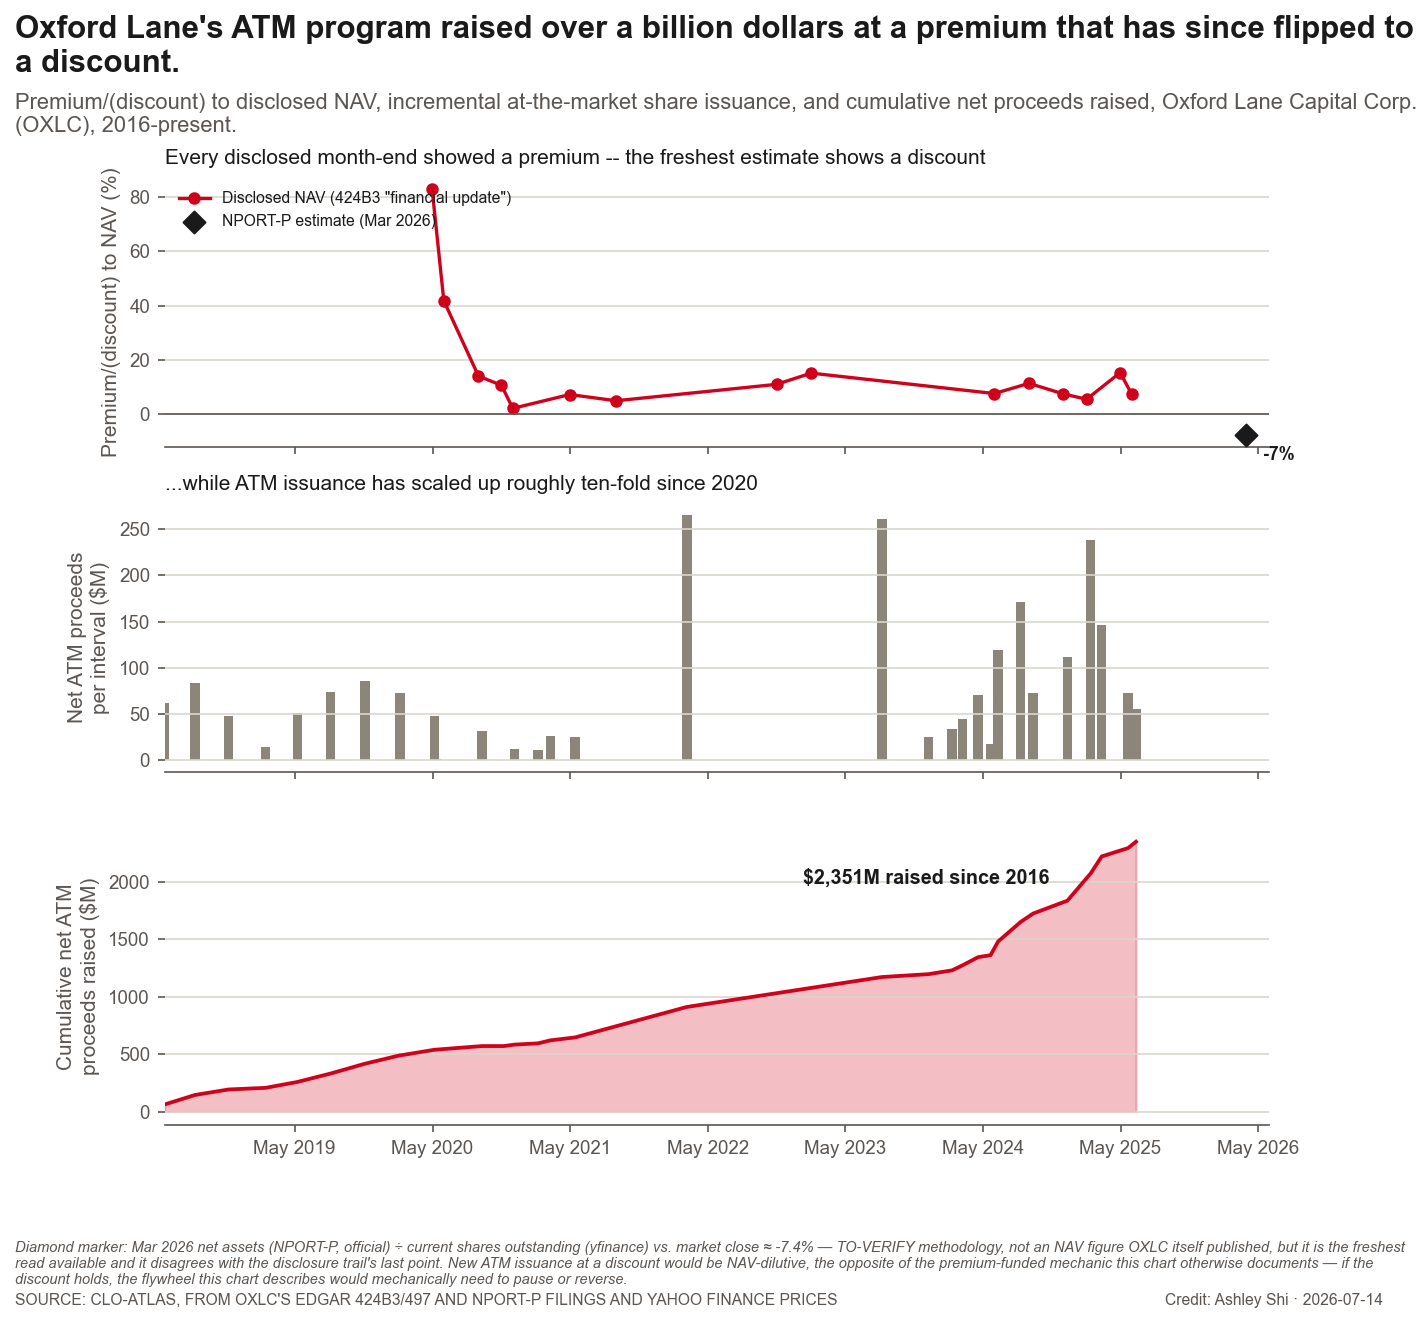

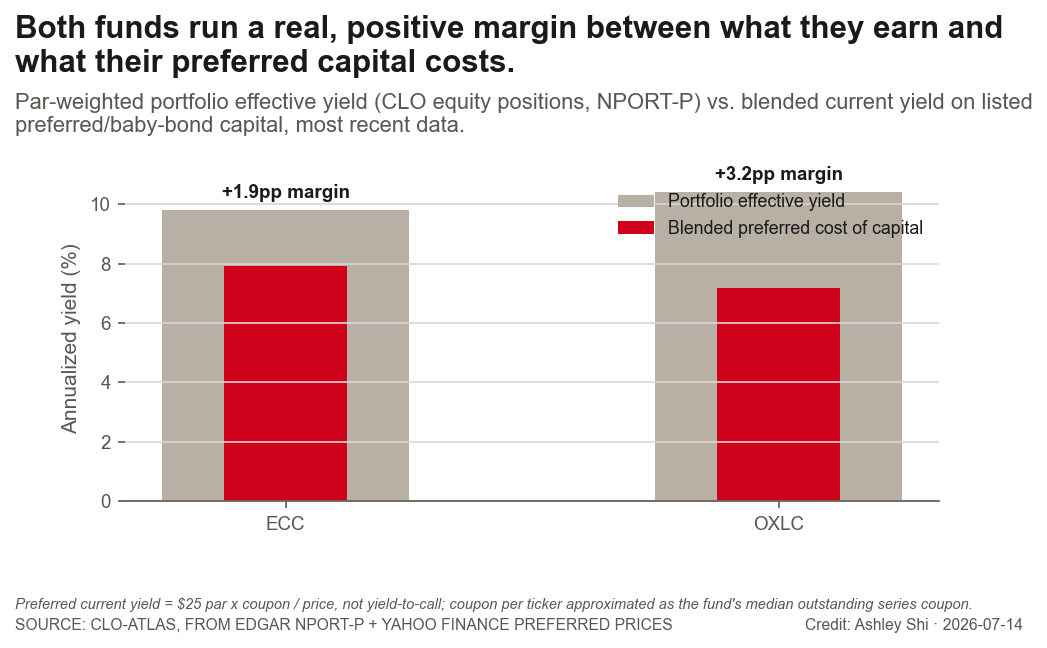

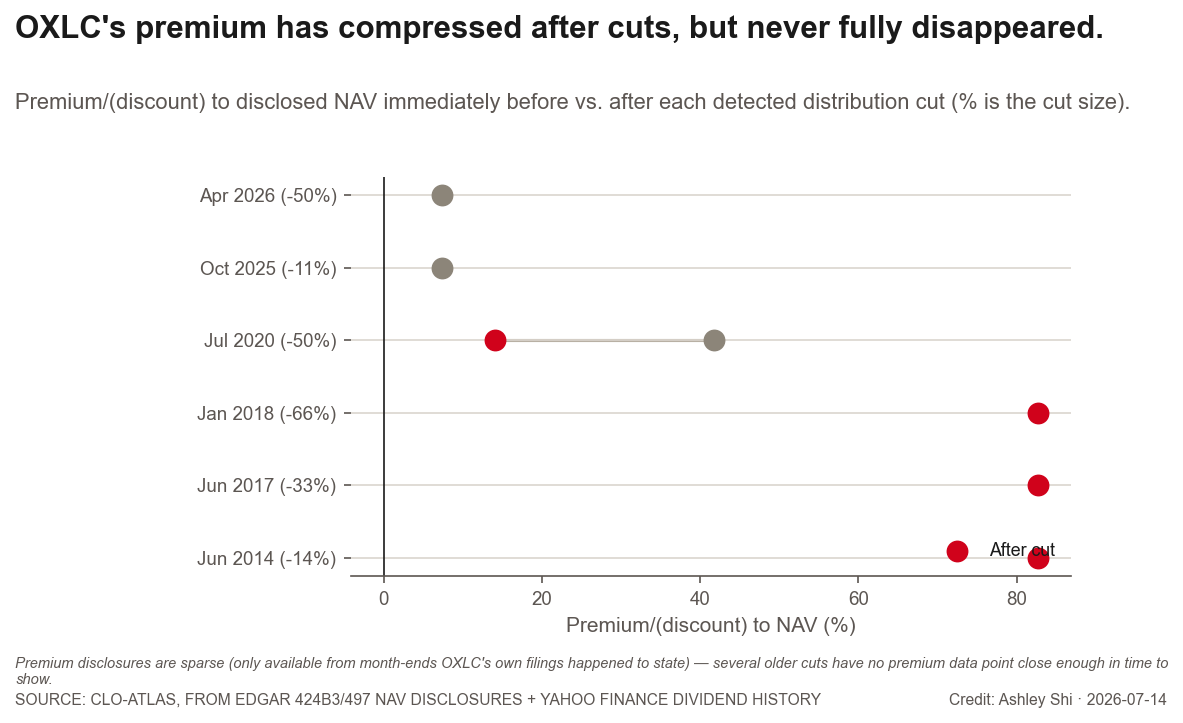

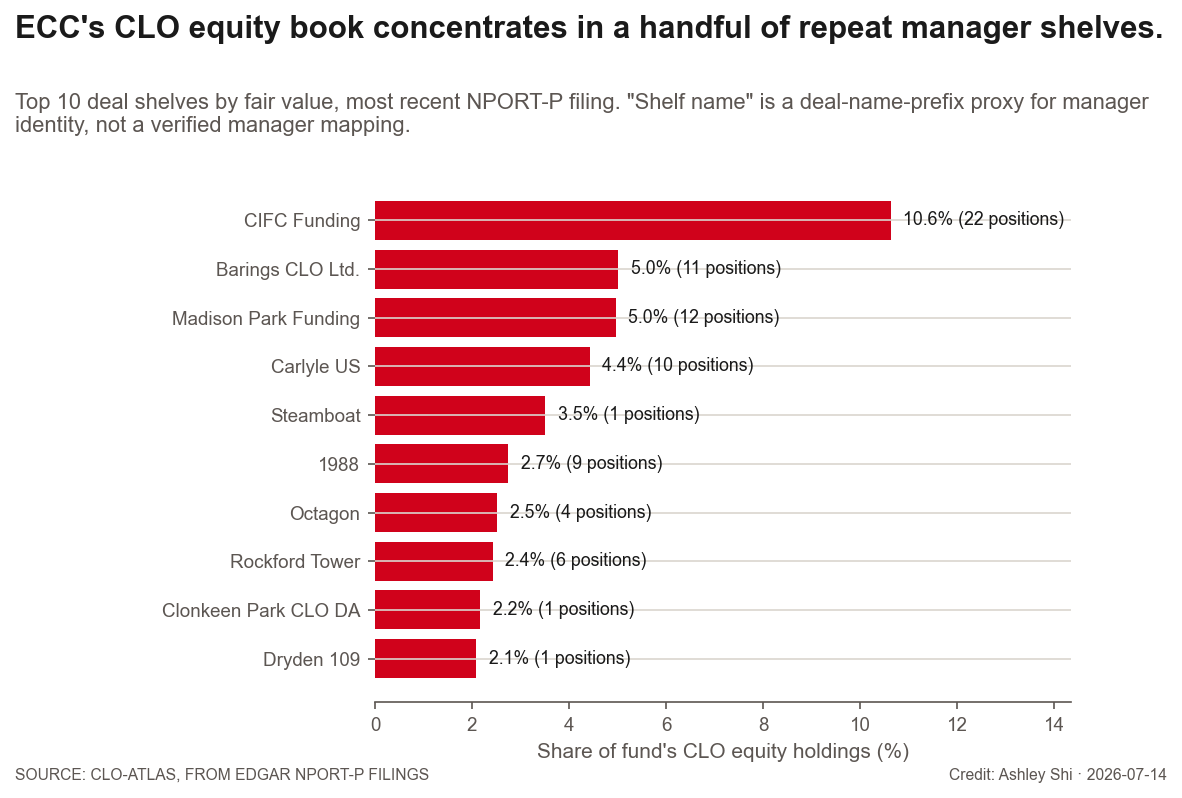

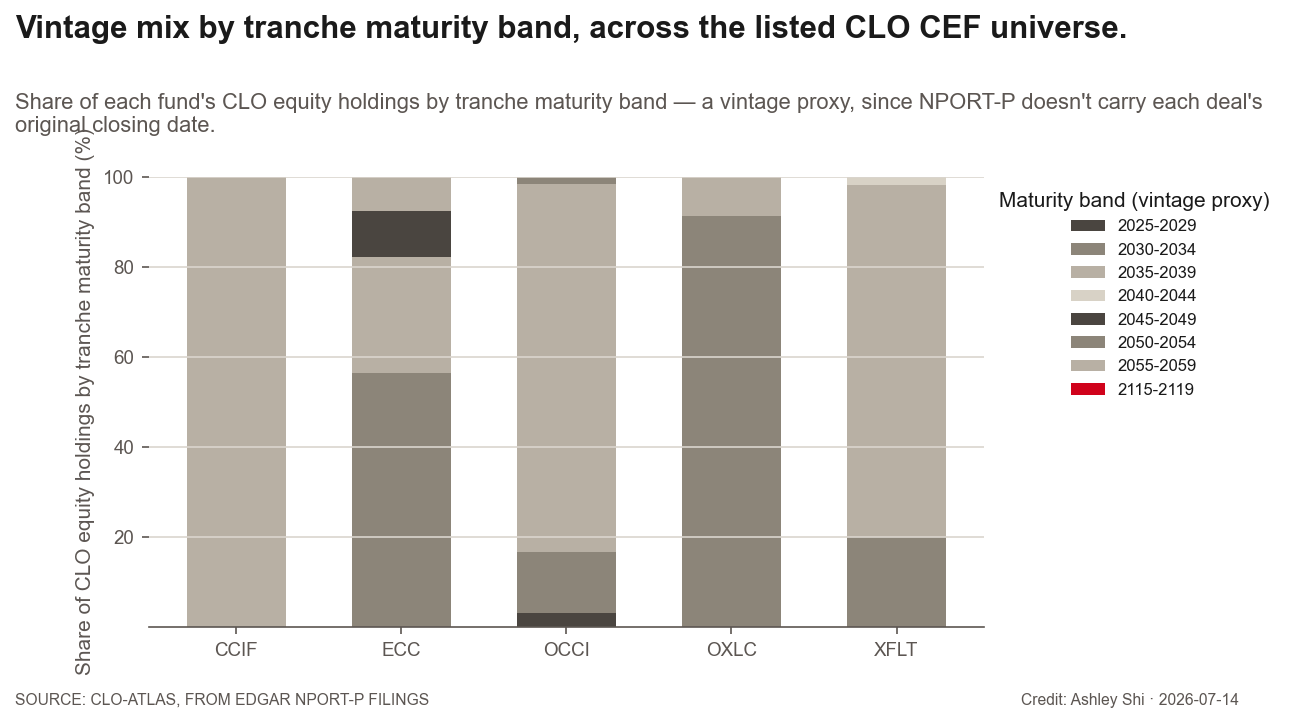

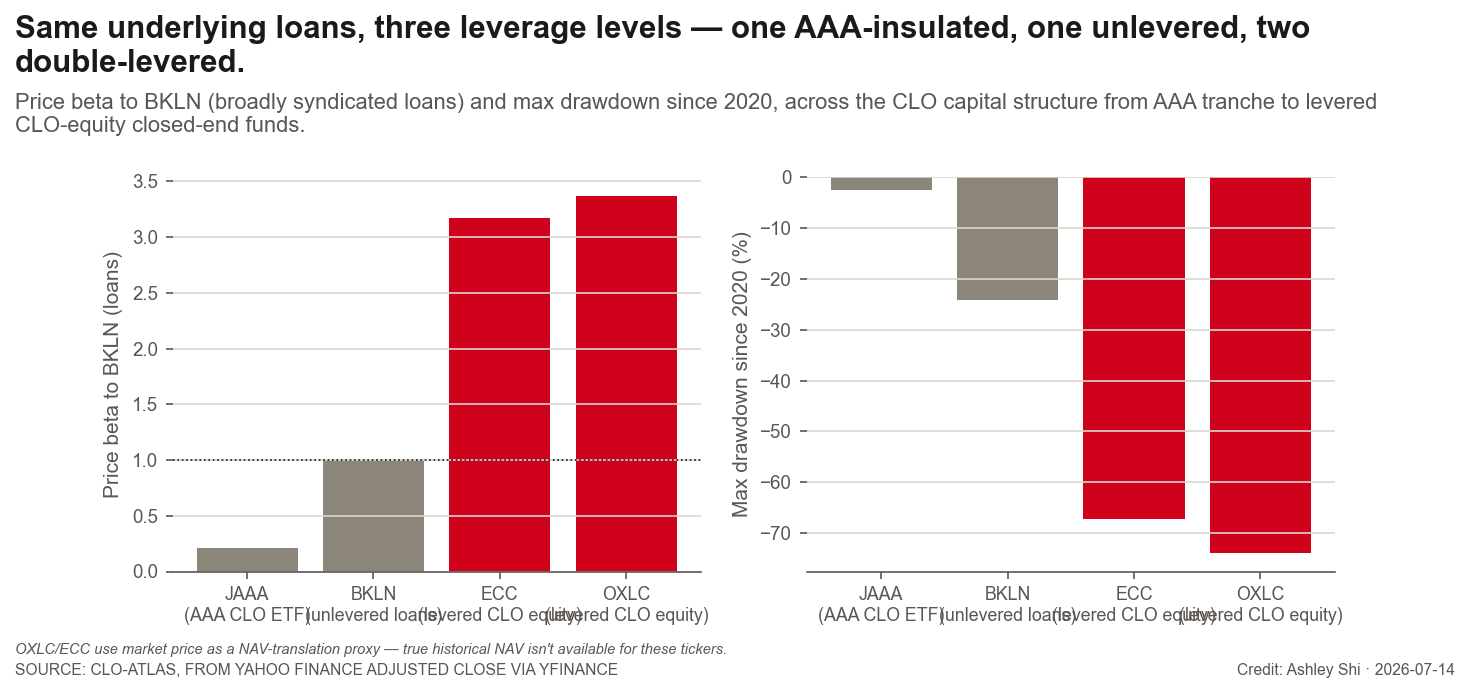

In [4]:
viz_flywheel.run()
viz_cost_of_capital.run()
viz_distribution.run()
viz_style.run()
viz_wrapper.run()


## Exhibits

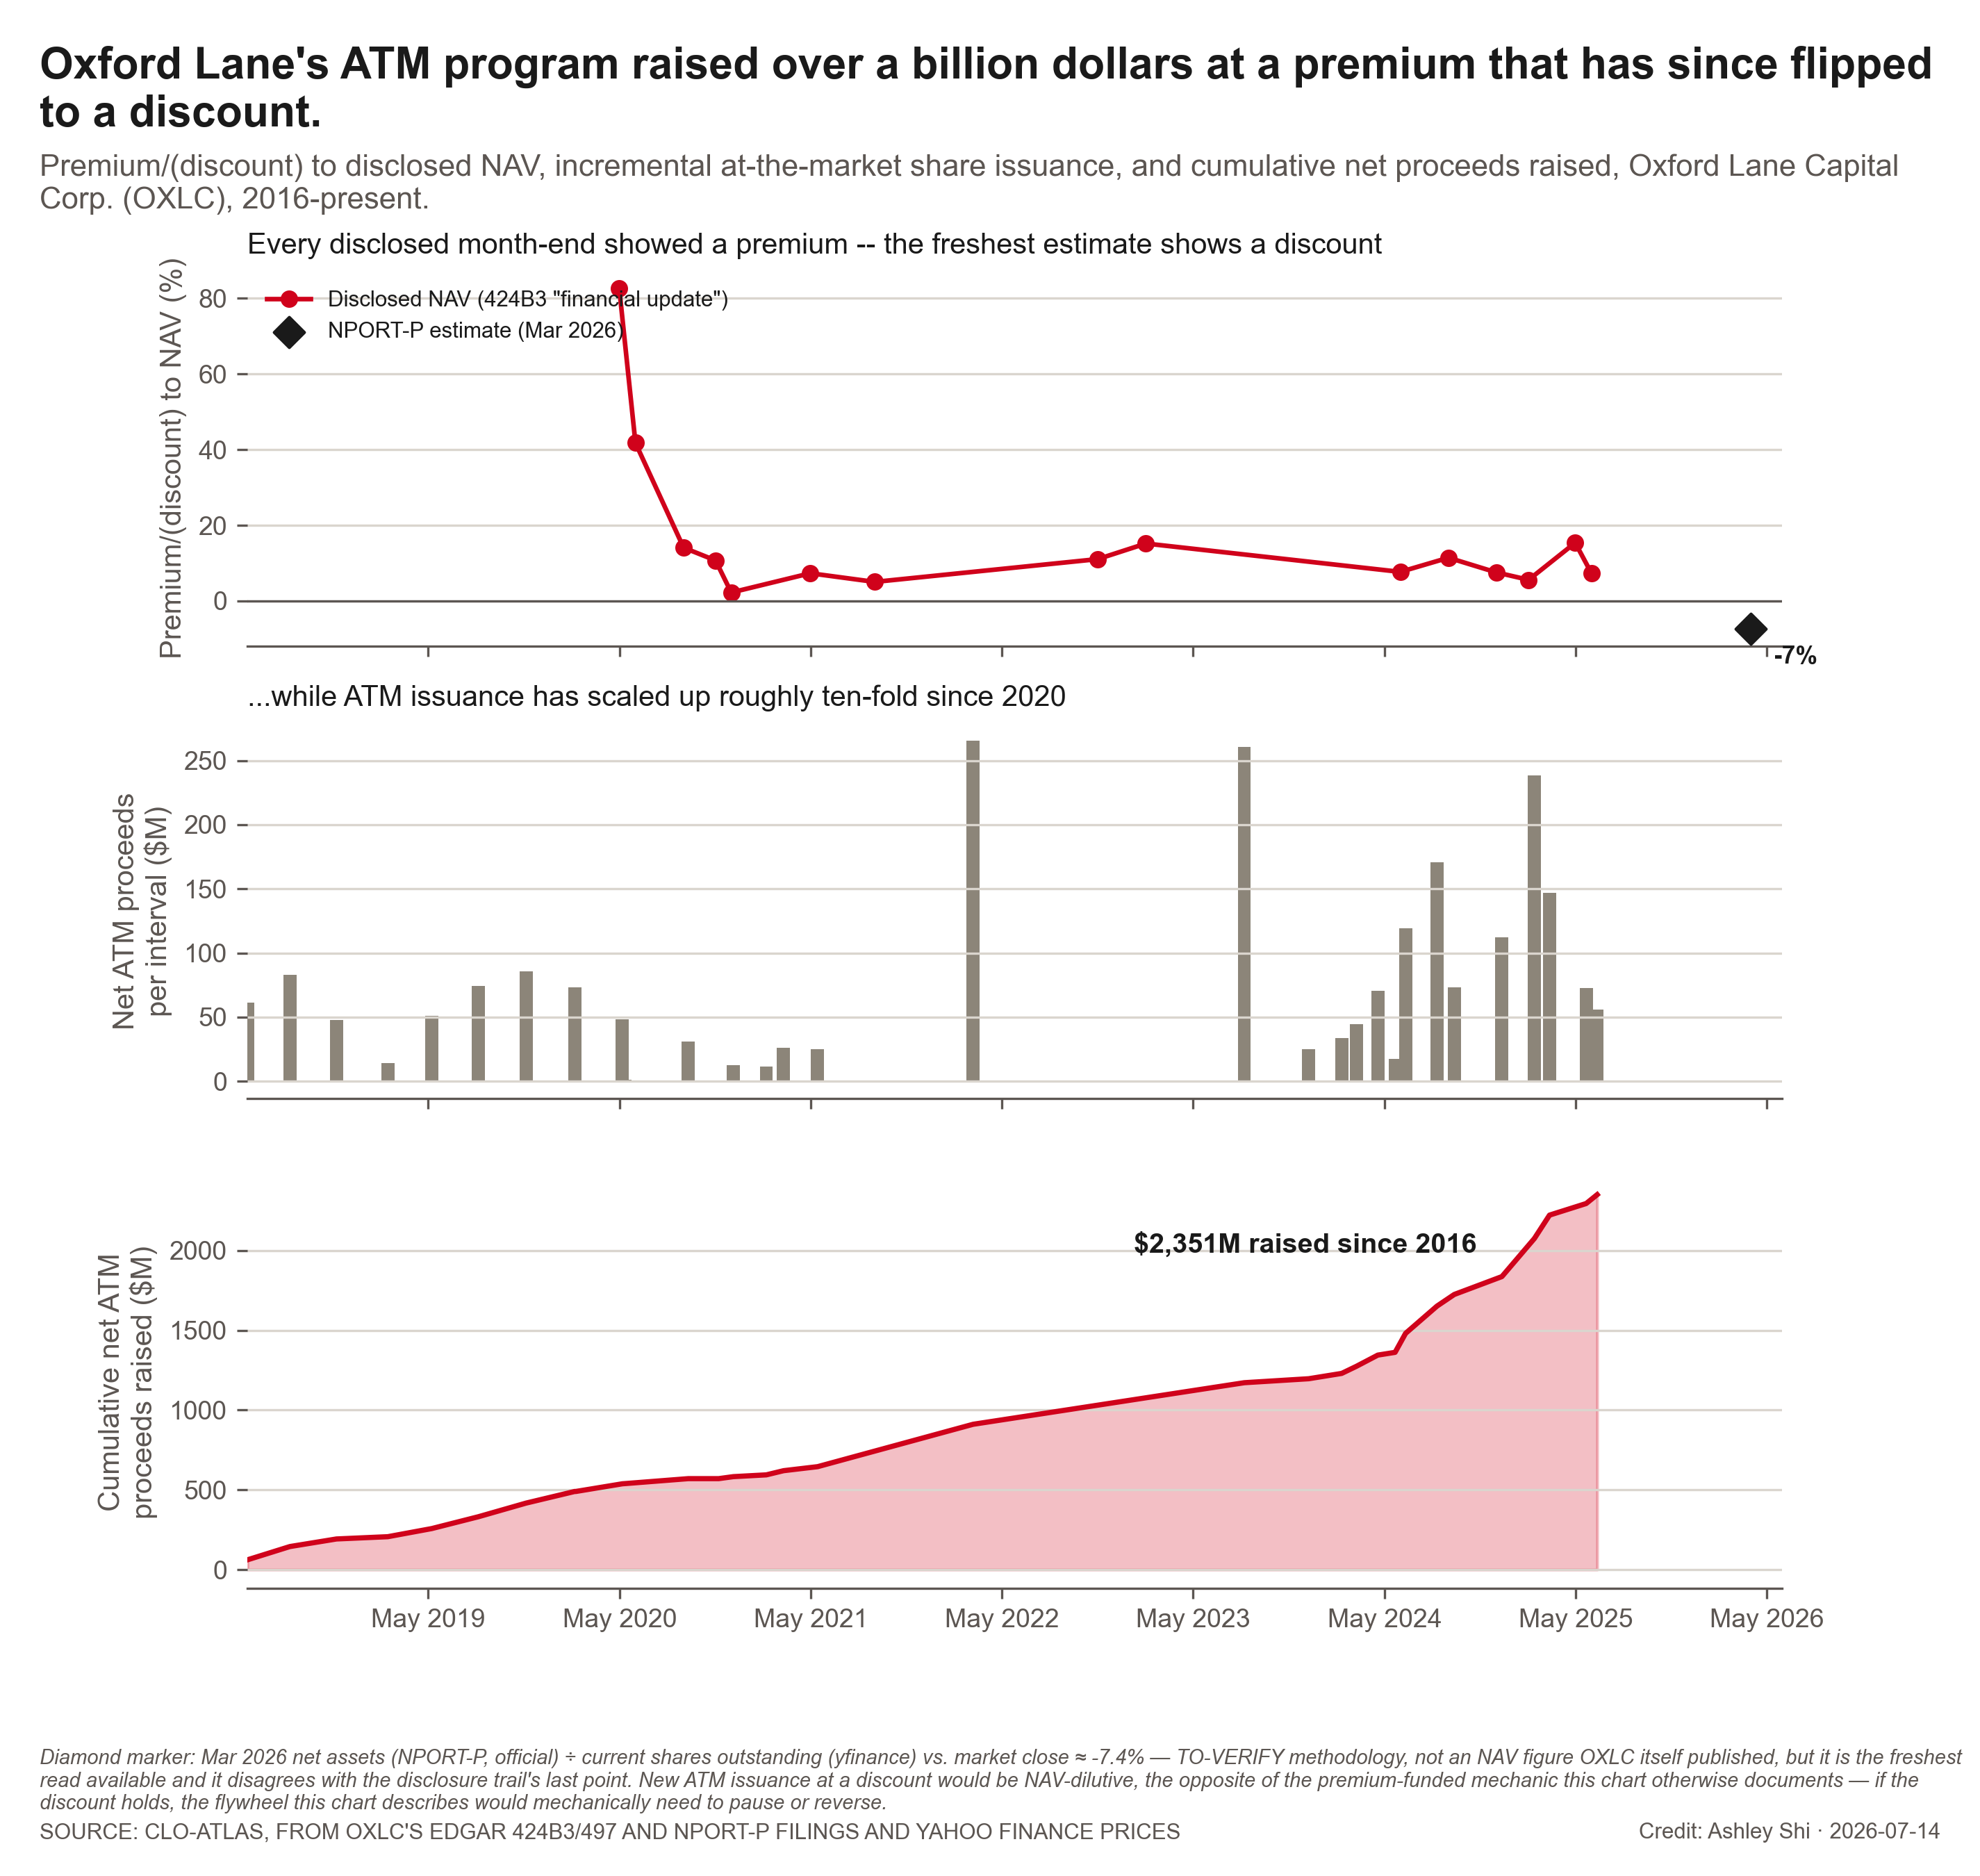

In [5]:
path = pathlib.Path("../figures") / "viz_flywheel.png"
if path.exists():
    display(Image(filename=str(path)))
else:
    print("[skipped — not generated this run] viz_flywheel")


**VERIFIED**: OXLC's own EDGAR 424B3/497 prospectus supplements disclose exact ATM shares sold and net proceeds since the prior supplement, plus scattered month-end NAV-per-share estimates; joined against Yahoo Finance market price (corrected for OXLC's 2025-09-08 1-for-5 reverse split — see the ledger's bug-fix row below), this yields a real historical premium series. Three aligned panels on one time axis show OXLC's premium to disclosed NAV at every observed month-end through May 2025 (always positive, 2%-plus), incremental ATM proceeds raised per interval, and the cumulative total — **$2,351M raised since 2016**. This is the mechanism: retail demand bids OXLC's shares up above NAV, and the company sells new shares into that premium, converting it directly into fresh primary-market CLO-equity buying power — permanent capital doing exactly what a flywheel does.

**The diamond marker is the update that matters right now.** OXLC's disclosure trail only refreshes when it files a new ATM supplement with a "financial update" paragraph, and that trail goes stale exactly when issuance slows — which is what happened after May 2025. The fund still files NPORT-P (portfolio holdings, net assets) quarterly regardless of ATM activity, so dividing the latest NPORT-P net-assets figure (Mar 2026, official, SEC-filed) by current shares outstanding gives a fresher, if **TO-VERIFY**, NAV-per-share estimate — and it disagrees sharply with the disclosure trail's last point: **≈-7% (a discount), not the persistent premium shown everywhere else on this chart.** This estimate is independently corroborated by Yahoo Finance's own `bookValue` figure for OXLC (\$10.56 vs. this project's \$10.56, and both show a discount at today's price). If the discount holds, the mechanism this chart otherwise documents runs in reverse: new ATM issuance at a discount is NAV-dilutive to existing holders, not accretive, which would argue for the flywheel pausing rather than continuing to spin.

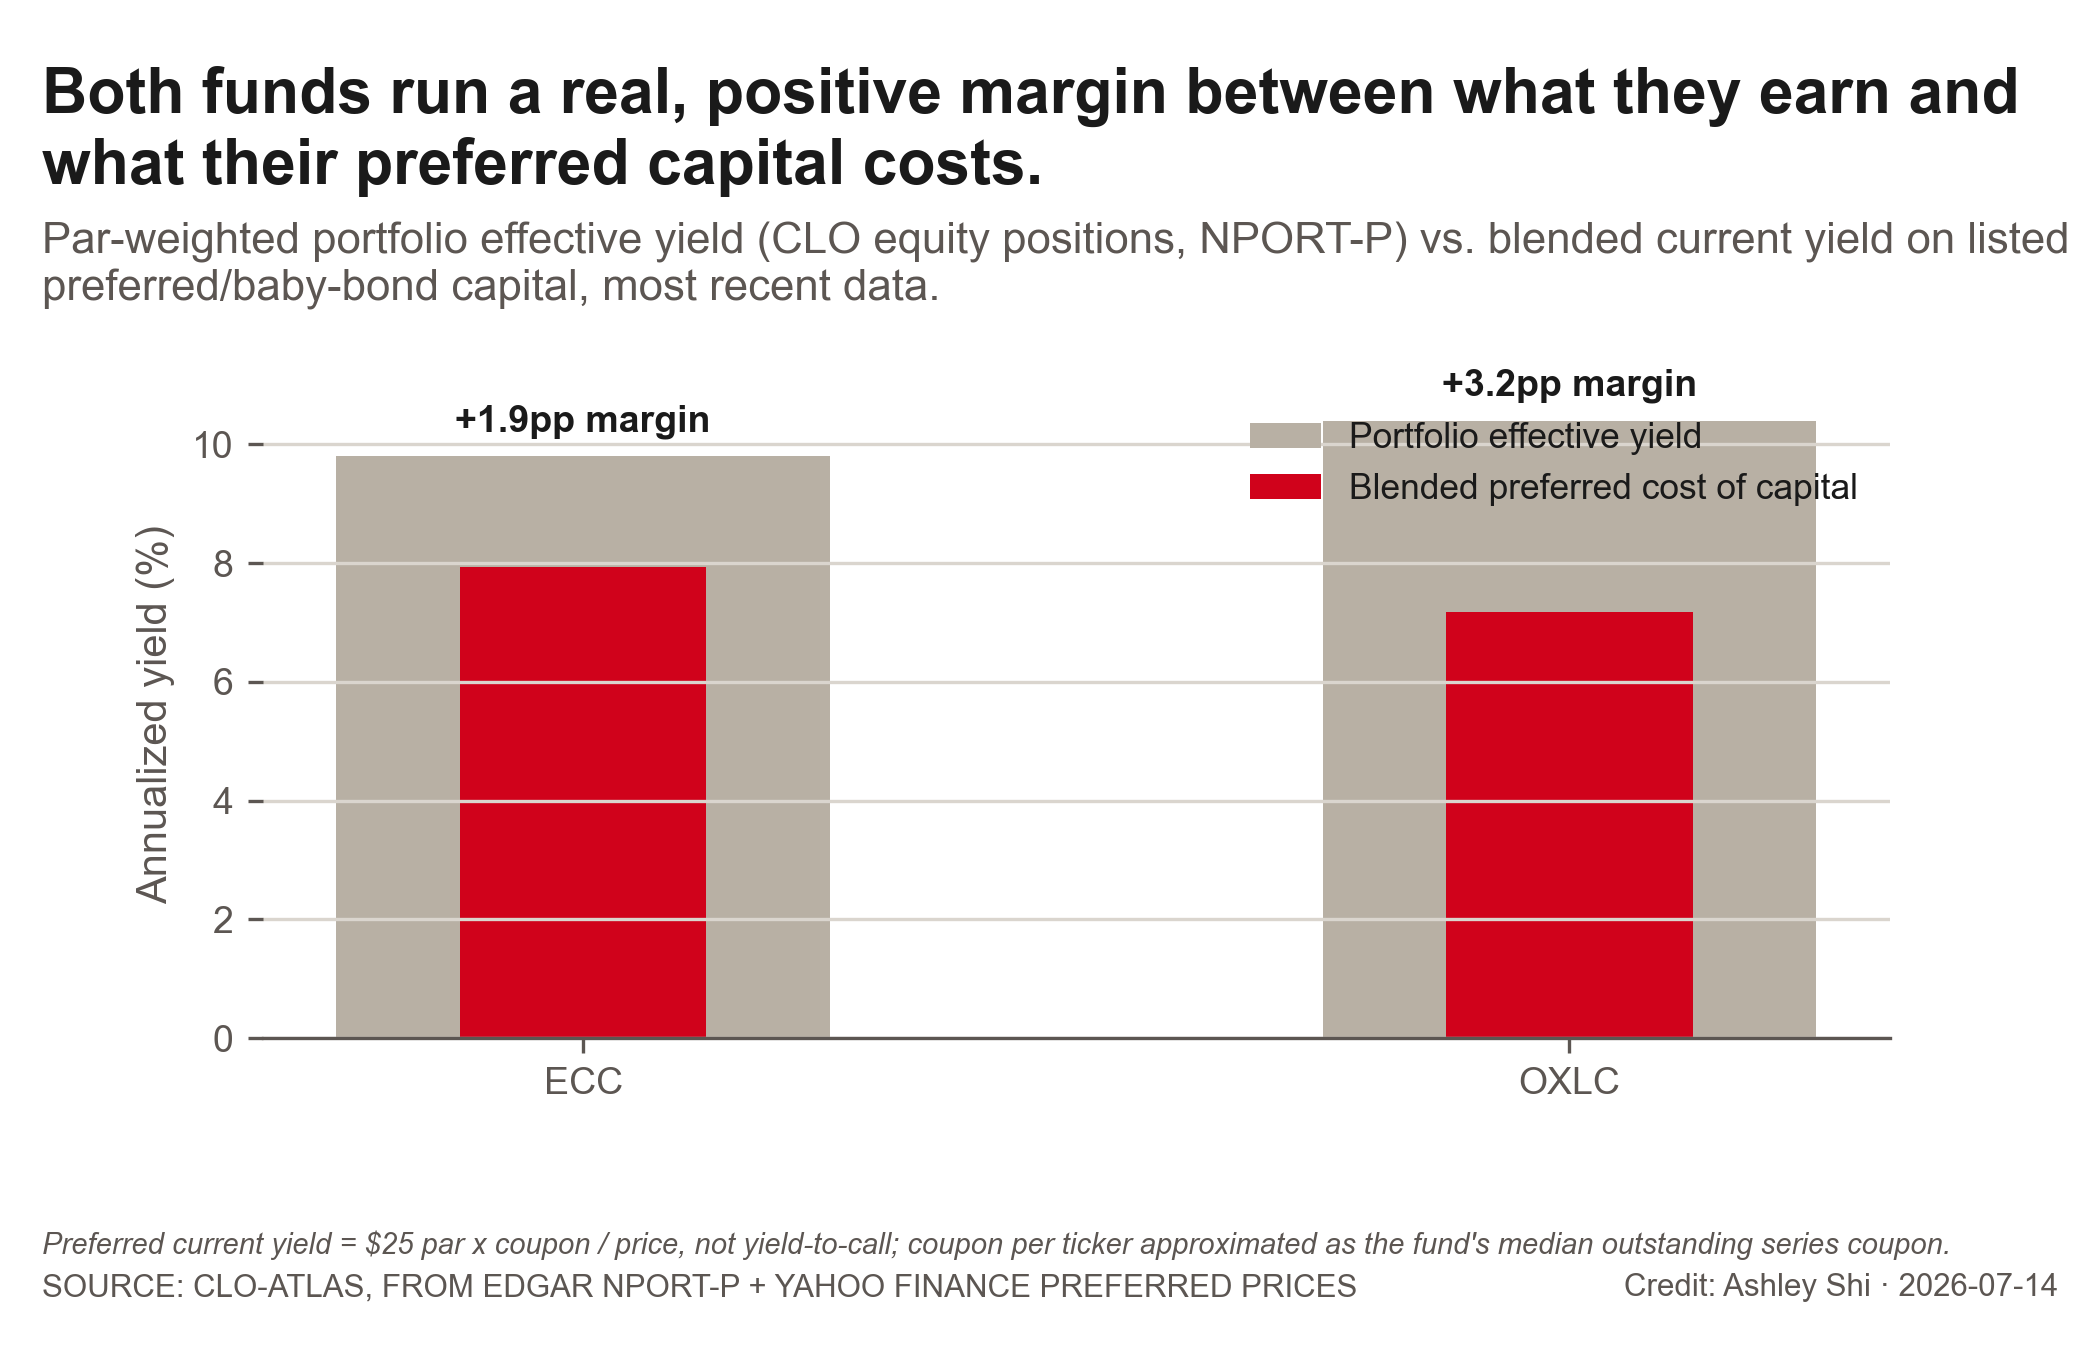

In [6]:
path = pathlib.Path("../figures") / "viz_cost_of_capital_margin.png"
if path.exists():
    display(Image(filename=str(path)))
else:
    print("[skipped — not generated this run] viz_cost_of_capital_margin")


**VERIFIED**: par-weighted portfolio effective yield on CLO-equity positions (EDGAR NPORT-P) against blended current yield on each fund's listed preferred/baby-bond capital (Yahoo Finance prices; coupon approximated as the fund's median outstanding series coupon, current yield not yield-to-call). The bar chart pairs the two yields for ECC (portfolio yield 9.8%) and OXLC (10.4%) against each fund's own blended preferred cost, with the margin annotated directly on each pair. That spread is the un-narrated mechanism behind the CEF wrapper: both funds earn a real, positive margin borrowing at preferred rates and investing in CLO equity, which is the leverage engine that makes CLO-CEF distributions possible in the first place.

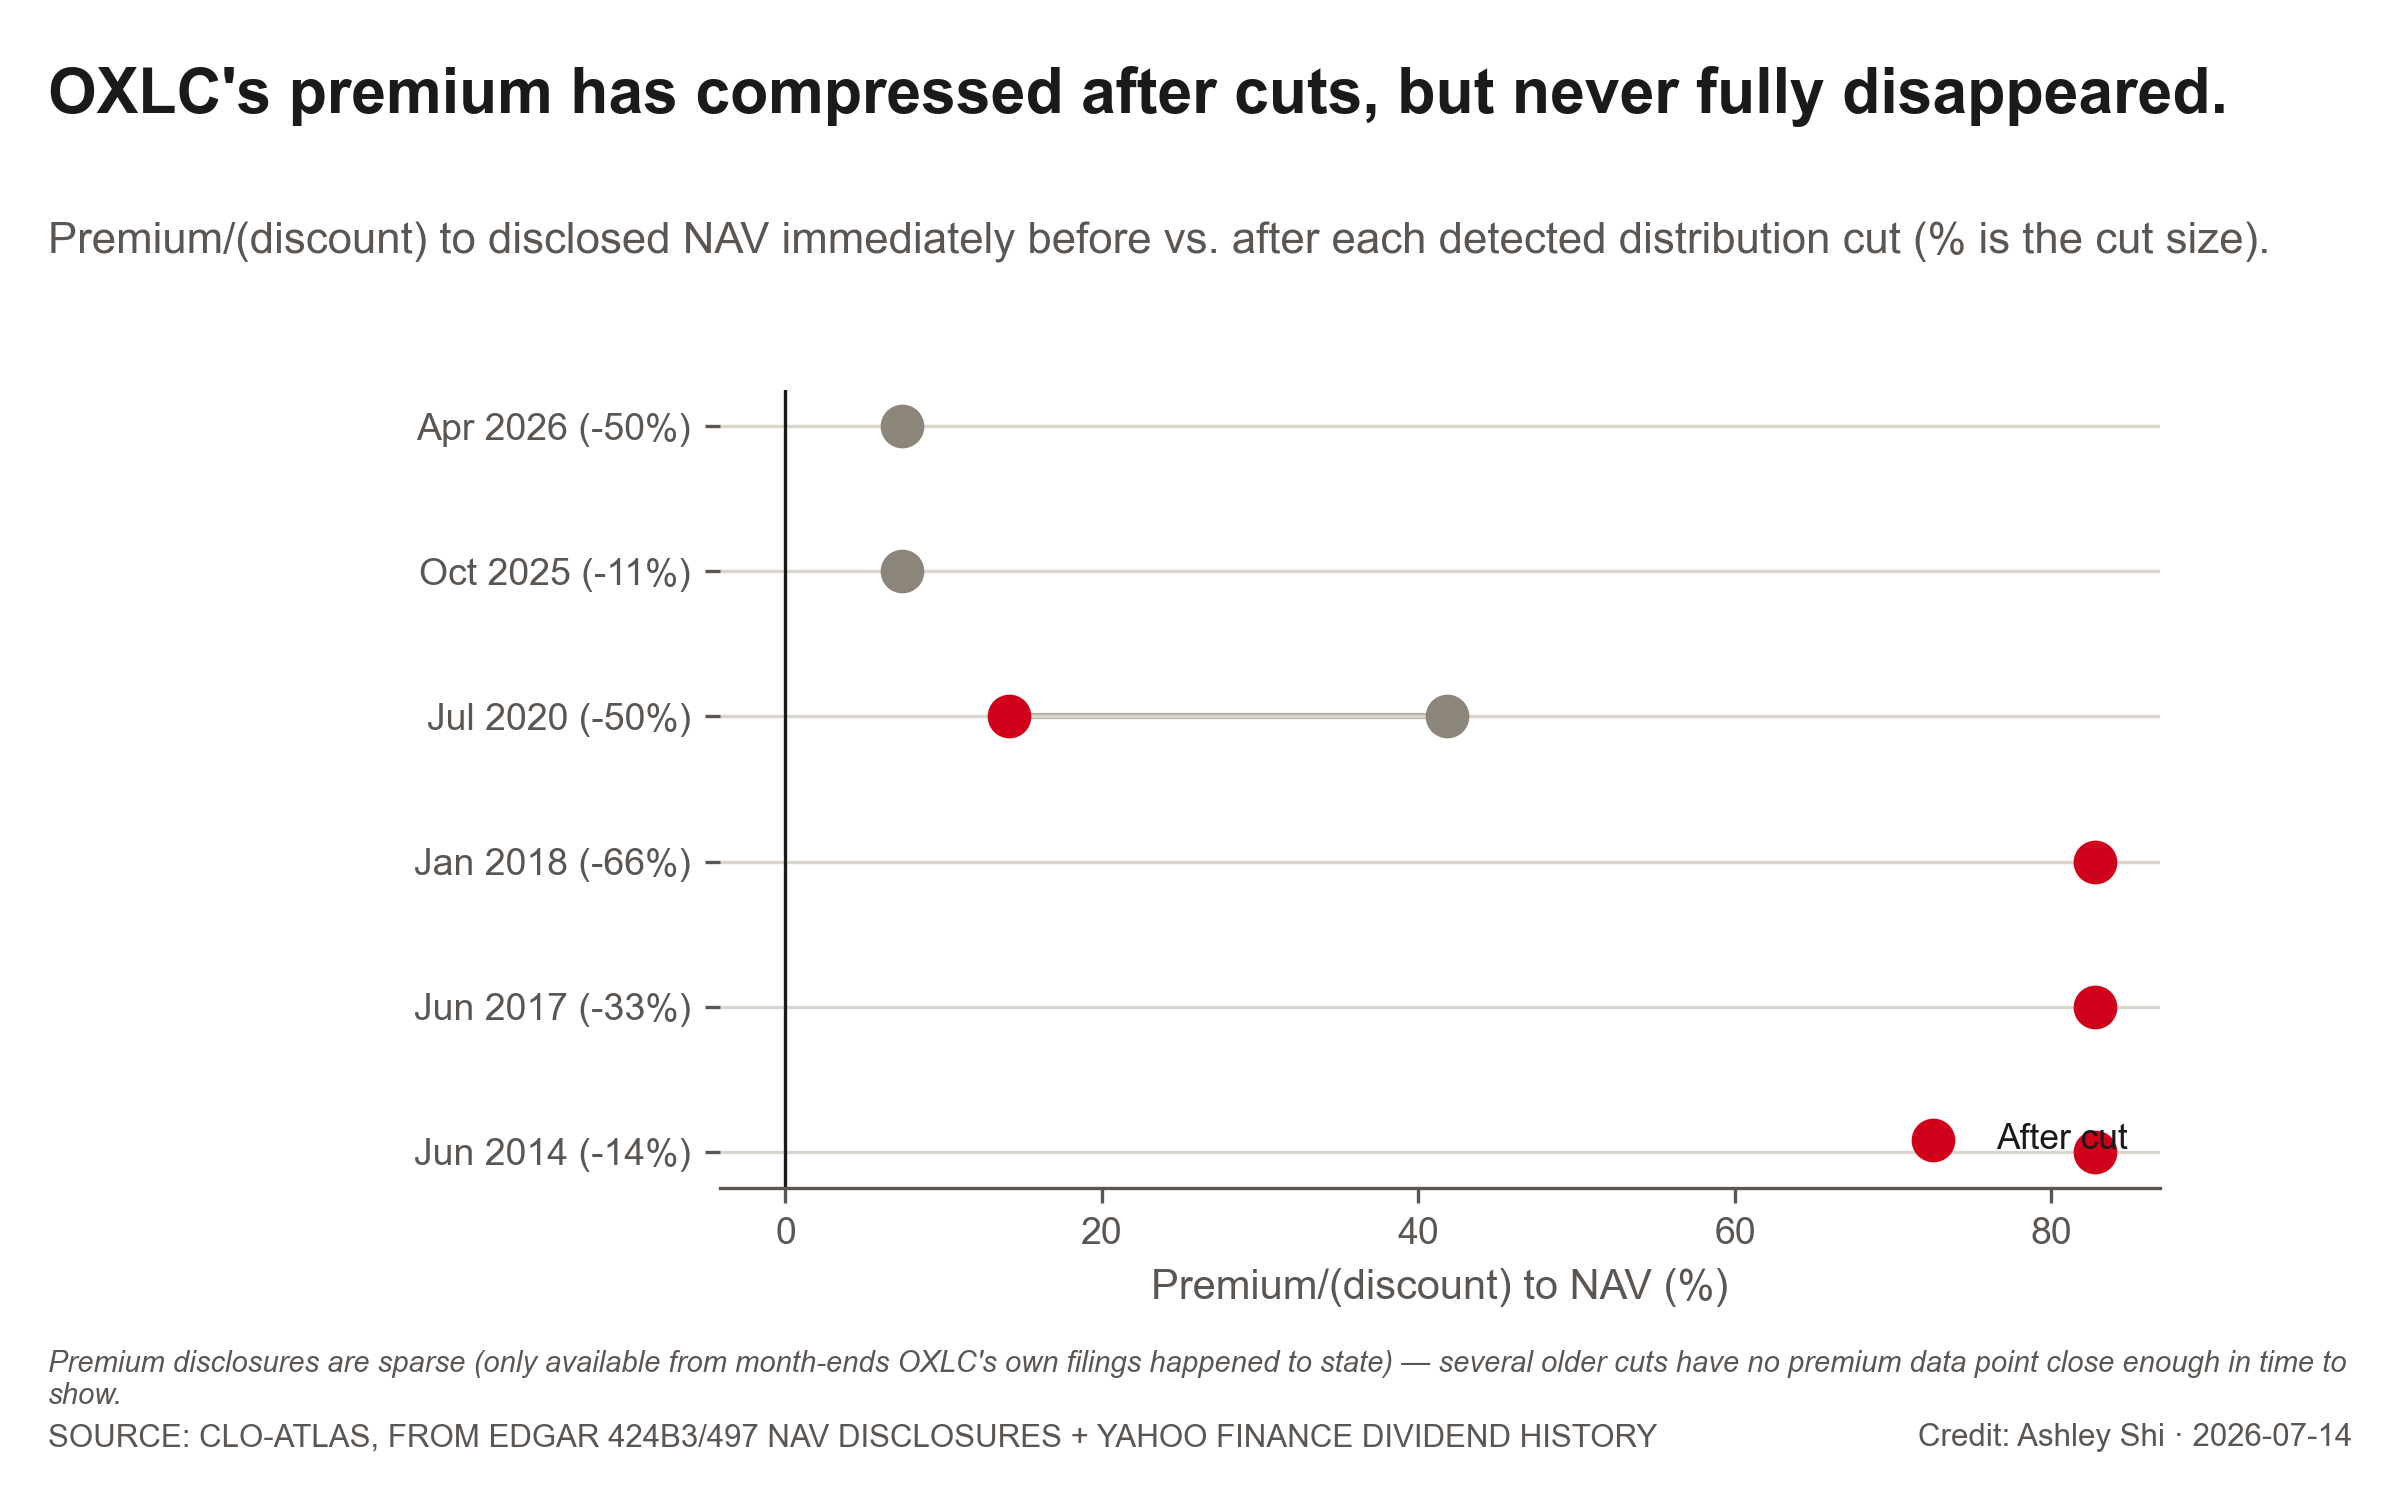

In [7]:
path = pathlib.Path("../figures") / "viz_distribution_cuts_vs_premium.png"
if path.exists():
    display(Image(filename=str(path)))
else:
    print("[skipped — not generated this run] viz_distribution_cuts_vs_premium")


**VERIFIED**: OXLC's premium/discount to disclosed NAV immediately before vs. after each detected distribution cut, from the same EDGAR 424B3/497 NAV disclosures and Yahoo Finance dividend history used in the flywheel exhibit — though premium data points are sparse, tied only to month-ends the filings happened to state, so several older cuts have no close-enough data point to plot. Each row is one cut, sized by percentage change, with a line connecting the premium before and after. The premium compresses after a cut but never fully disappears, which answers a natural skeptic's question about the flywheel chart above: distribution cuts erode, but don't kill, the premium that funds OXLC's ATM issuance.

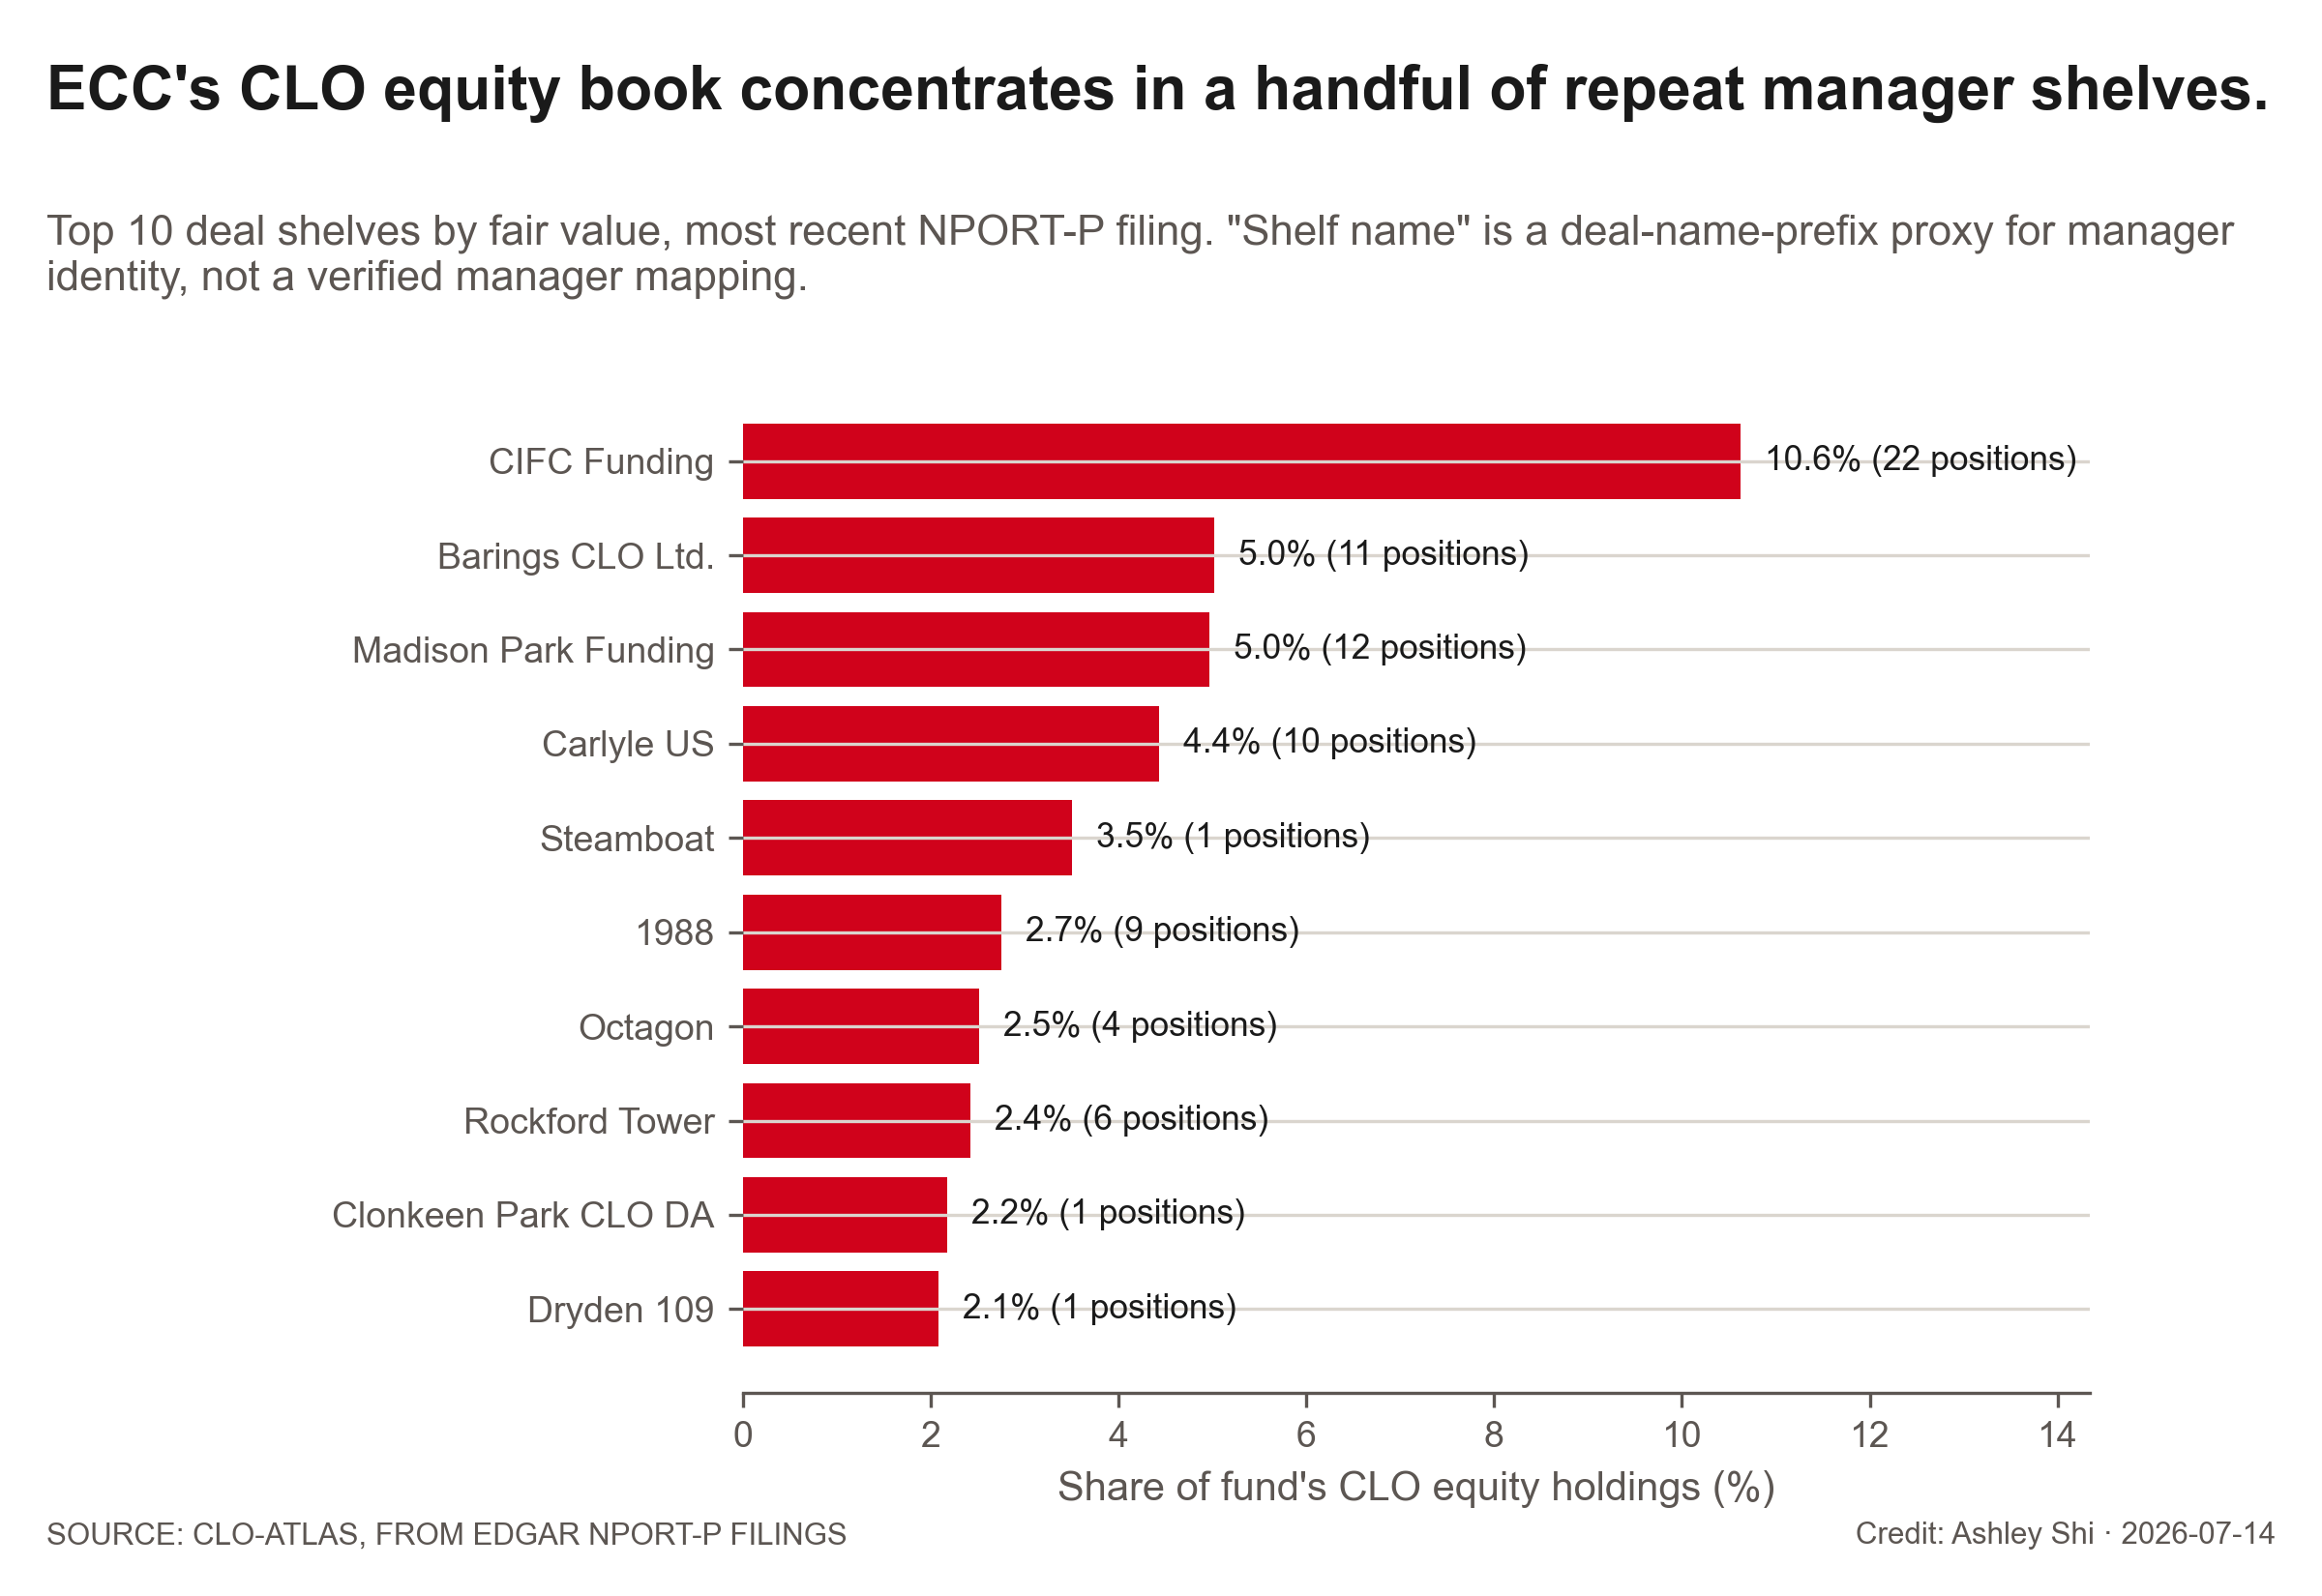

In [8]:
path = pathlib.Path("../figures") / "viz_shelf_concentration.png"
if path.exists():
    display(Image(filename=str(path)))
else:
    print("[skipped — not generated this run] viz_shelf_concentration")


**VERIFIED**, with a named proxy caveat: fair value by CLO deal shelf from ECC's most recent NPORT-P filing, where "shelf name" is a deal-name-prefix heuristic standing in for CLO manager identity, not a verified issuer-to-manager mapping (`analysis_portfolio_style.py`). The horizontal bar chart ranks ECC's top 10 shelves by share of the fund's total CLO-equity holdings, with position counts annotated per bar. It shows that even a diversified CLO-equity CEF concentrates in a handful of repeat manager relationships — a reminder that "CLO equity" as an asset class is really manager-selection risk wrapped inside a fund structure.

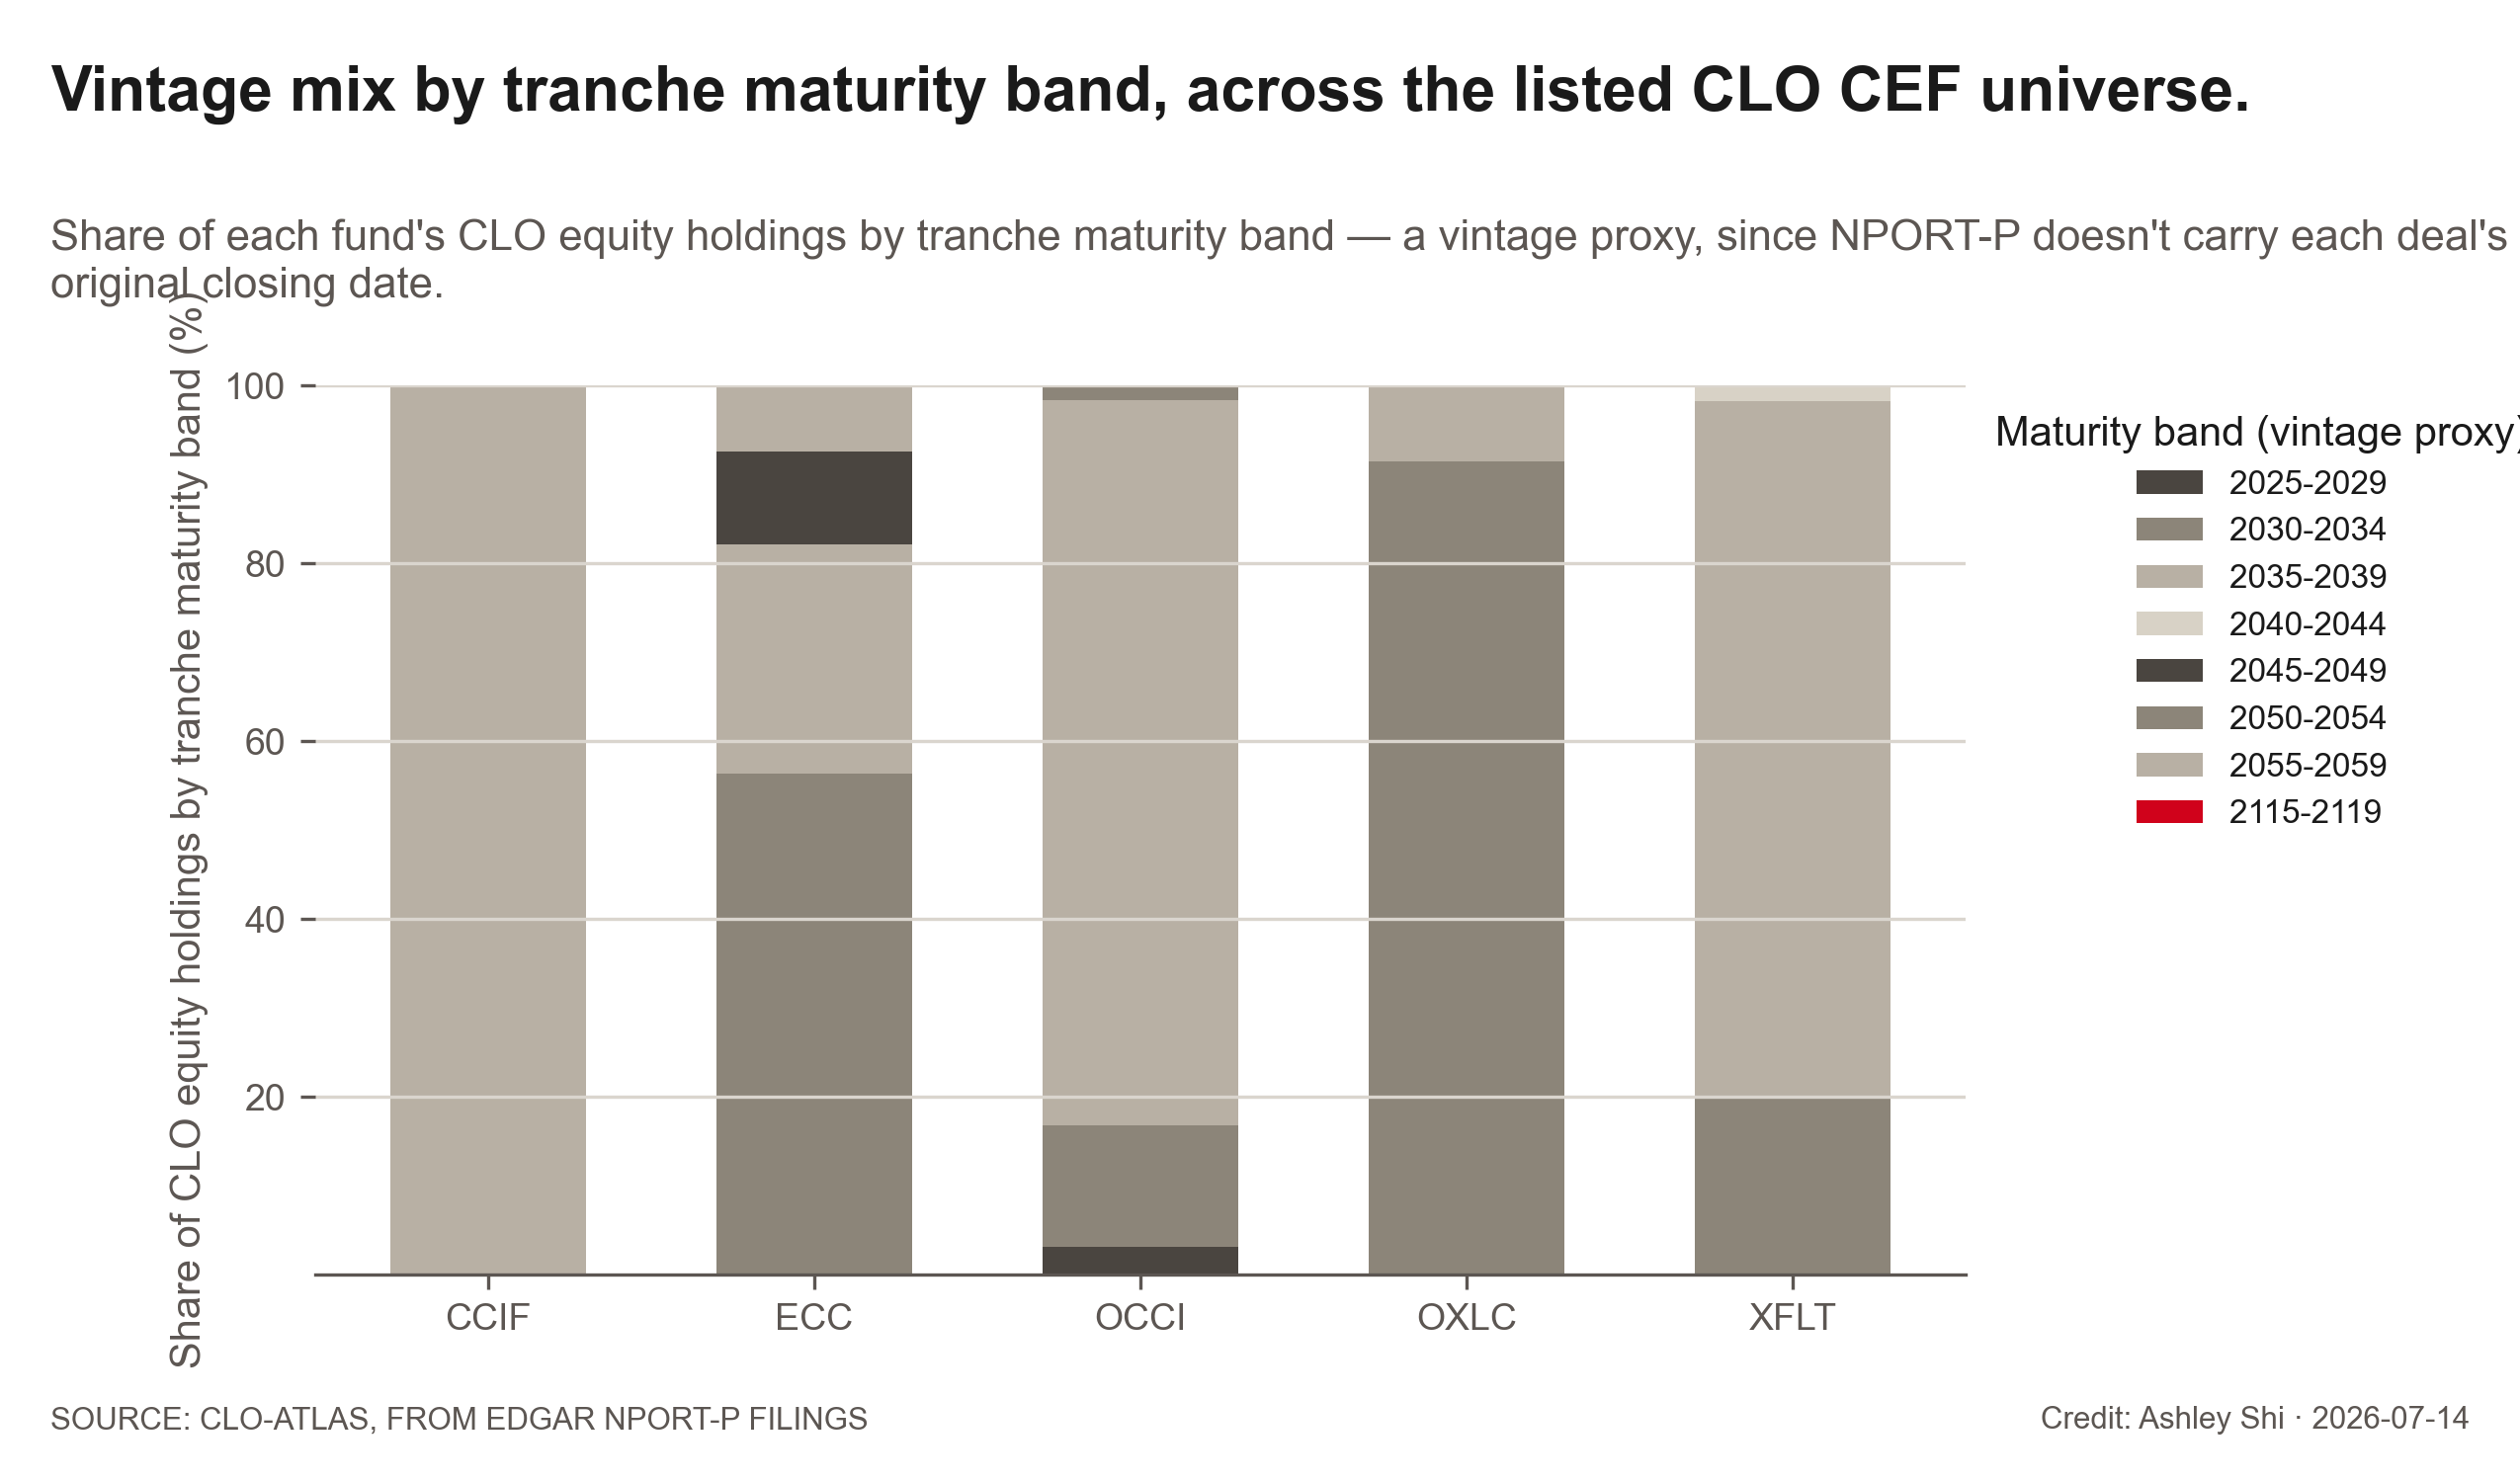

In [9]:
path = pathlib.Path("../figures") / "viz_vintage_mix.png"
if path.exists():
    display(Image(filename=str(path)))
else:
    print("[skipped — not generated this run] viz_vintage_mix")


**VERIFIED**: share of each fund's CLO-equity holdings by tranche maturity band, from EDGAR NPORT-P filings — used here as a vintage proxy, since NPORT-P doesn't disclose each deal's original closing date. The stacked bar chart compares maturity-band composition across the tracked CLO CEF universe, one bar per fund. Maturity-band mix is a rough stand-in for how exposed each fund is to CLOs originated in different rate/spread environments — a genuine risk differentiator between funds that otherwise look similar on yield alone.

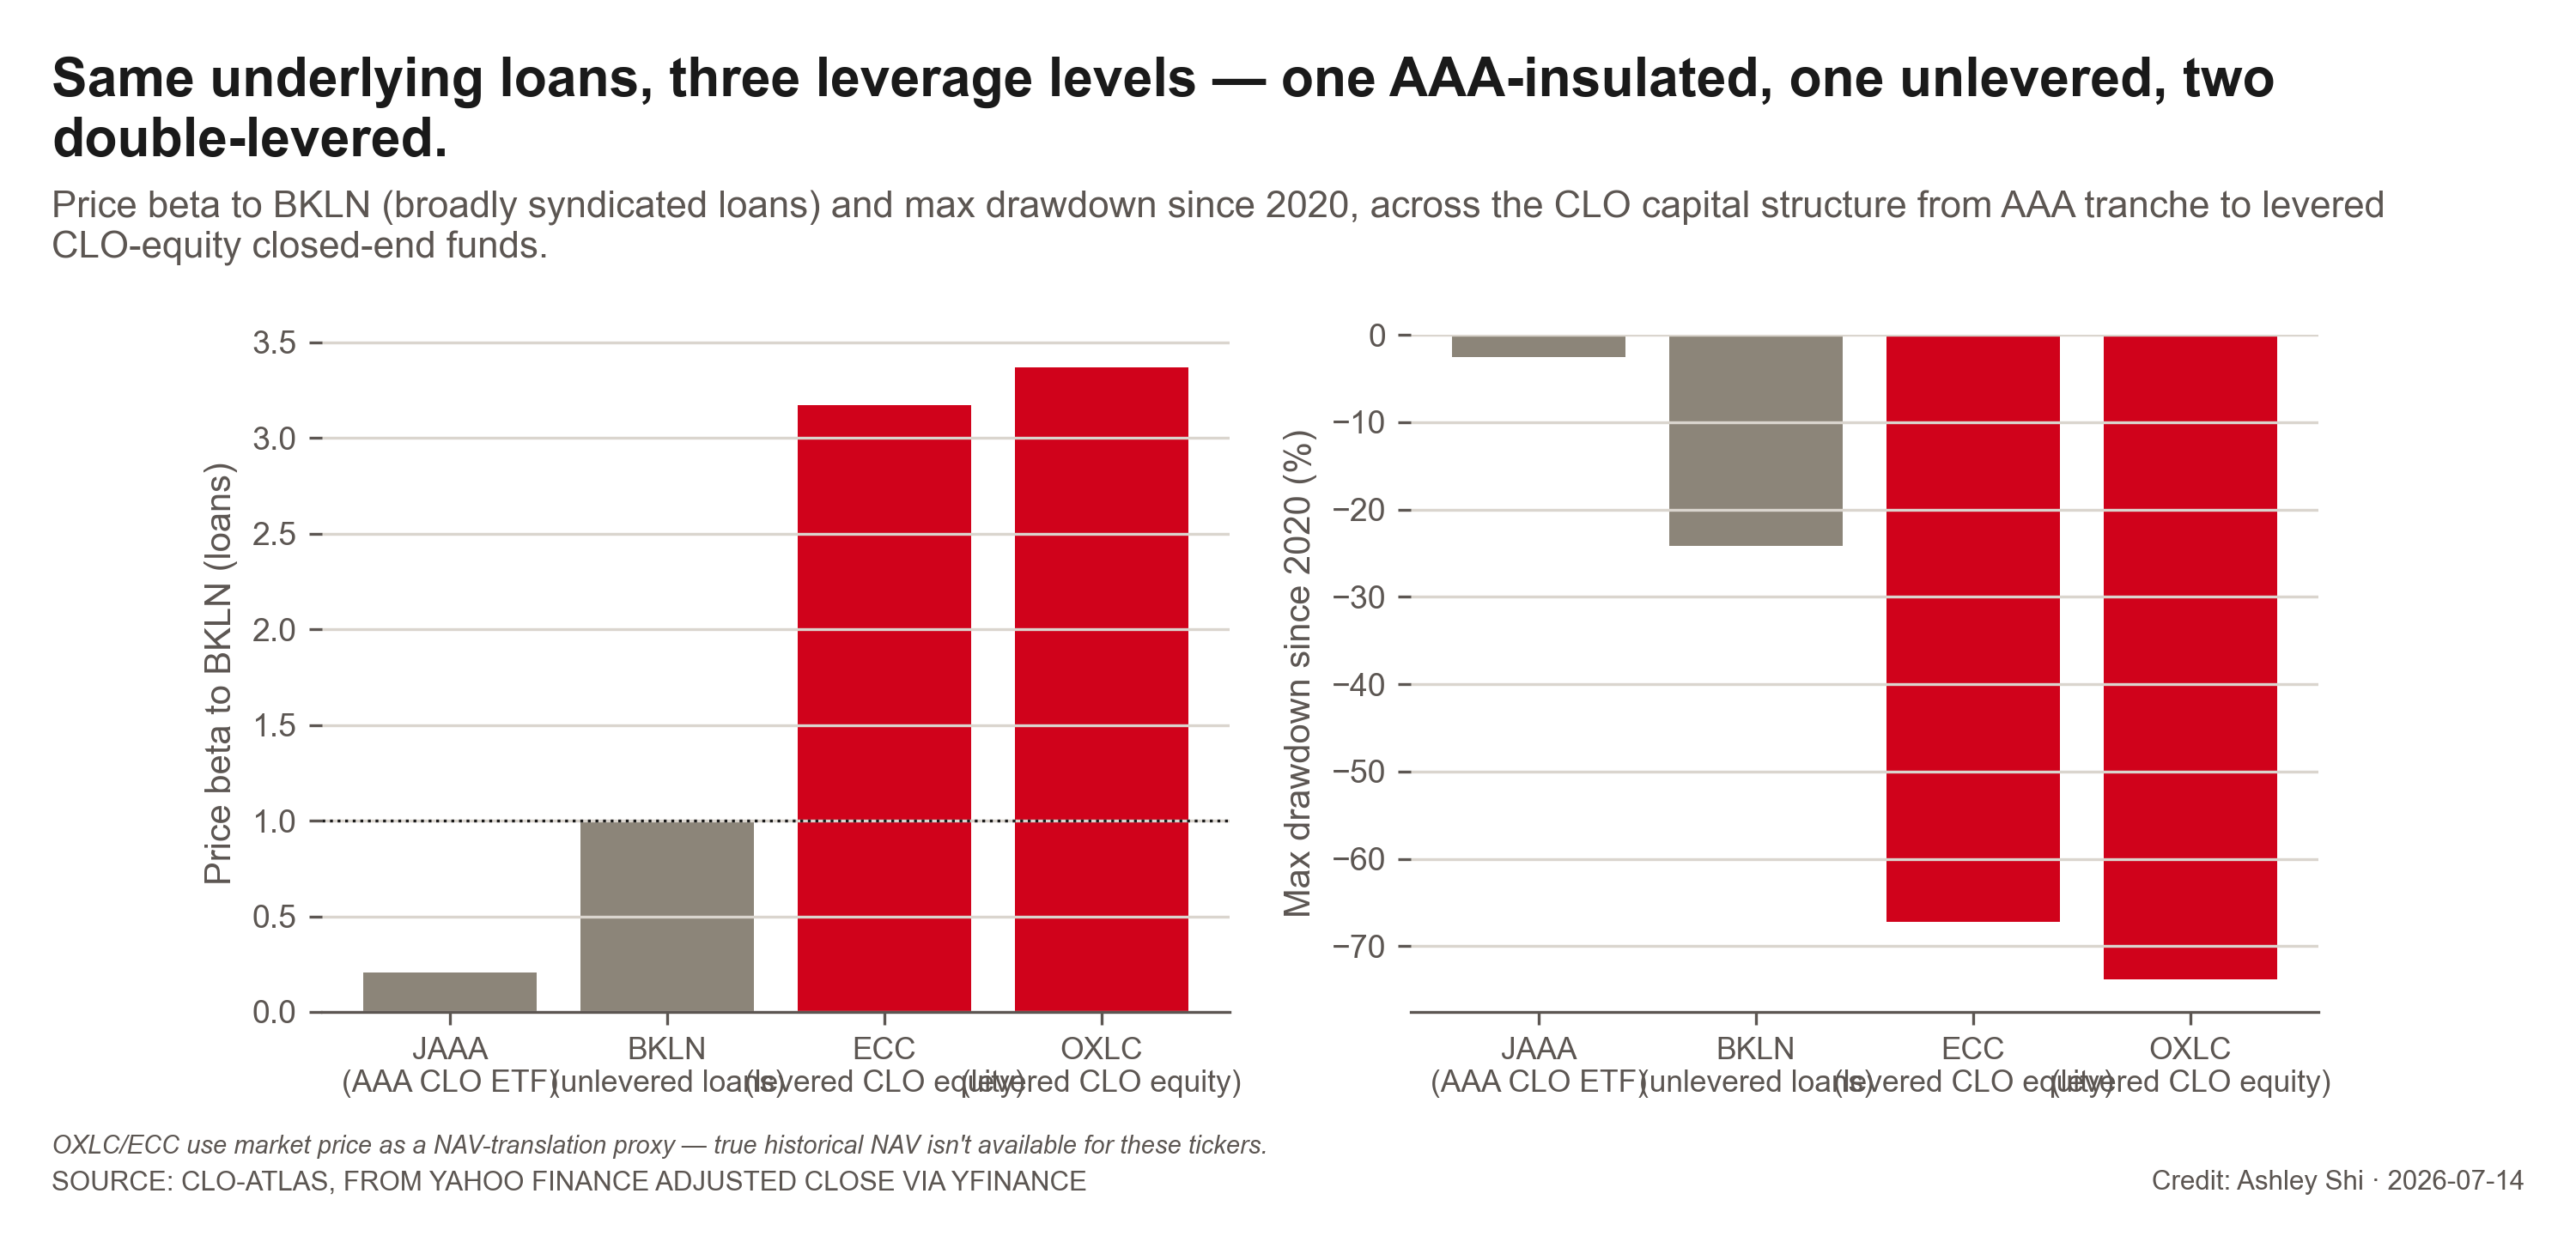

In [10]:
path = pathlib.Path("../figures") / "viz_leverage_gradient.png"
if path.exists():
    display(Image(filename=str(path)))
else:
    print("[skipped — not generated this run] viz_leverage_gradient")


**VERIFIED**: price beta to BKLN (unlevered broadly syndicated loans) and max drawdown since 2020, computed from Yahoo Finance adjusted-close history for JAAA, BKLN, ECC, and OXLC (OXLC/ECC use market price as a NAV-translation proxy, since true historical NAV isn't available for these tickers). Two panels place all four instruments on the same axis: JAAA's beta to loans near 0.21 (AAA-tranche insulation), BKLN at 1.00 by construction, and ECC/OXLC both above 3x (double-levered CLO equity). Lined up like this, the four tickers teach the entire CLO capital structure through instruments an ordinary brokerage account can actually buy — same underlying loan collateral, wildly different risk depending on where in the stack the capital sits.

## VERIFIED / TO-VERIFY ledger

Every number appearing in this section's exhibits, including the split-adjustment bug fix and the demand-transmission chain's stated gap.

In [11]:
cef_deep_dive_ledger = ledger.run()
cef_deep_dive_ledger


,value,computation_or_citation,as_of,tag
0,"$2,351M raised via OXLC's ATM program since 2016",analysis_capital_machine.incremental_issuance(...,2025-06-11 00:00:00,VERIFIED
1,"Every disclosed premium is positive, range 2% ...","analysis_capital_machine.premium_history(), re...",n/a,VERIFIED
2,Bug caught and fixed: unrescaled comparison ag...,see analysis_capital_machine.py docstring and ...,n/a,VERIFIED
3,ECC: portfolio yield 9.8% vs. blended preferre...,analysis_cost_of_capital.cost_of_capital_margin(),n/a,VERIFIED
4,OXLC: portfolio yield 10.4% vs. blended prefer...,analysis_cost_of_capital.cost_of_capital_margin(),n/a,VERIFIED
5,JAAA: price beta to BKLN = 0.21,analysis_nav_translation.price_beta_to_loans()...,n/a,VERIFIED
6,OXLC: price beta to BKLN = 3.37,analysis_nav_translation.price_beta_to_loans()...,n/a,VERIFIED
7,ECC: price beta to BKLN = 3.17,analysis_nav_translation.price_beta_to_loans()...,n/a,VERIFIED
8,BKLN: price beta to BKLN = 1.00,analysis_nav_translation.price_beta_to_loans()...,n/a,VERIFIED
9,CCIF: >=5%-holder institutional floor 26.1%,"analysis_ownership.institutional_floor(), from...",n/a,VERIFIED
